In [26]:
# Imports necesarios para el notebook
import random

from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import scipy as sp
from John_Jellicoe import algoritmo_JJ
from backtracking import resolver_tablero

from auxiliares import generate_test_case

from util import time_algorithm

# Siempre seteamos la seed de aleatoridad para que los # resultados sean reproducibles
random.seed(12345)
np.random.seed(12345)

sns.set_theme()

In [27]:

# Generate test sizes
import time

OFFSET_N_M = 3
K_BOATS = 15

x = np.linspace(1, 20, 10).astype(int)

results = {}

for size in x:
    start_time = time.time()
    n, m, ship_lengths, row_restrictions, col_restrictions = generate_test_case(3, size, 15)
    original_row_demands, original_column_demands = row_restrictions.copy(), col_restrictions.copy()
    tablero, demanda_restante = algoritmo_JJ(n, m, ship_lengths, row_restrictions, col_restrictions)
    result = resolver_tablero(ship_lengths, original_row_demands, original_column_demands, sum(original_row_demands), sum(original_column_demands))
    end_time = time.time()
    results[size] = end_time - start_time
    demanda_cumplida = sum(original_row_demands) + sum(original_column_demands) - demanda_restante

    # print("Demanda cumplida JJ", demanda_cumplida,"Demanda cumplida BT",result["demanda_cumplida"])

    cota = demanda_cumplida / result["demanda_cumplida"]
    
    print(cota)


1.0
0.5
0.5
0.3888888888888889
0.9545454545454546
0.7142857142857143
0.5714285714285714
0.47368421052631576
0.7191011235955056
0.5958904109589042


KeyError: 'size'

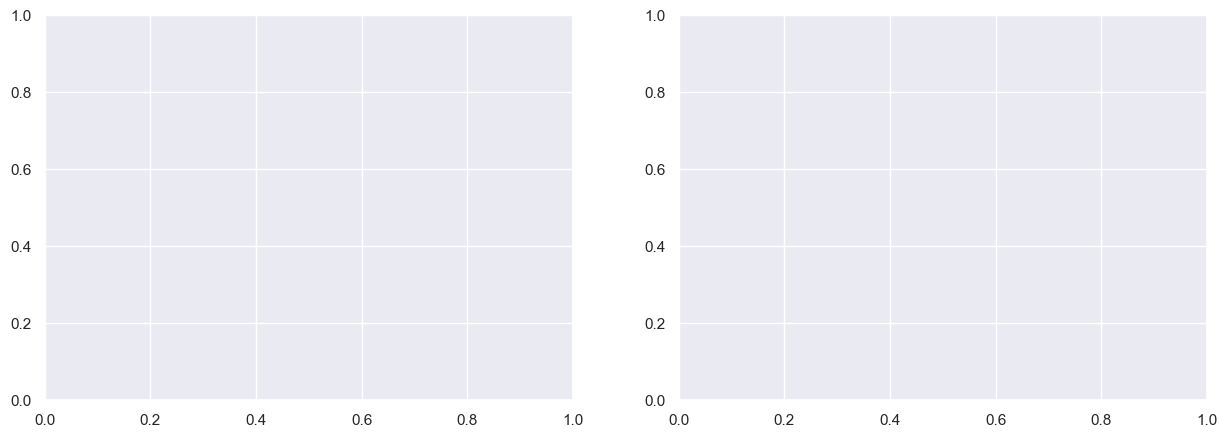

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(results['size'], results['jj_time'], label='Algorimo JJ')
ax1.plot(results['size'], results['backtrack_time'], label='Backtracking (Óptimo)')
ax1.set_title('Tiempo de ejecución')
ax1.set_xlabel('Tamaño del problema')
ax1.set_ylabel('Tiempo')
ax1.legend()
# ax1.set_yscale('log')

# Plot optimality ratio
ax2.plot(results['size'], results['optimality_ratio'])
ax2.set_title('Relación JJ/Backtracking en optimalidad')
ax2.set_xlabel('Tamaño del problema')
ax2.set_ylabel('Cota')
ax2.axhline(y=1.0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()


Text(0, 0.5, 'Tiempo de ejecución (s)')

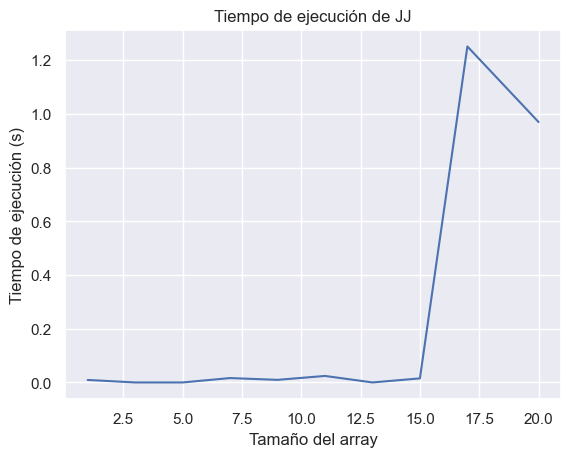

In [ ]:
ax: plt.Axes
fig, ax = plt.subplots()
ax.plot(x, [results[i] for i in x], label="Medición")
ax.set_title('Tiempo de ejecución de JJ')
ax.set_xlabel('Tamaño del array')
ax.set_ylabel('Tiempo de ejecución (s)')


In [ ]:
# scipy nos pide una función que recibe primero x y luego los parámetros a ajustar:
f = lambda x, c1, c2: c1 * x * np.log(x) + c2 

c, pcov = sp.optimize.curve_fit(f, x, [results[n] for n in x])

print(f"c_1 = {c[0]}, c_2 = {c[1]}")
r = np.sum((c[0] * x * np.log(x) + c[1] - [results[n] for n in x])**2)
print(f"Error cuadrático total: {r}")

c_1 = 0.01714875861042633, c_2 = -0.20457928038733064
Error cuadrático total: 0.9182790280775894


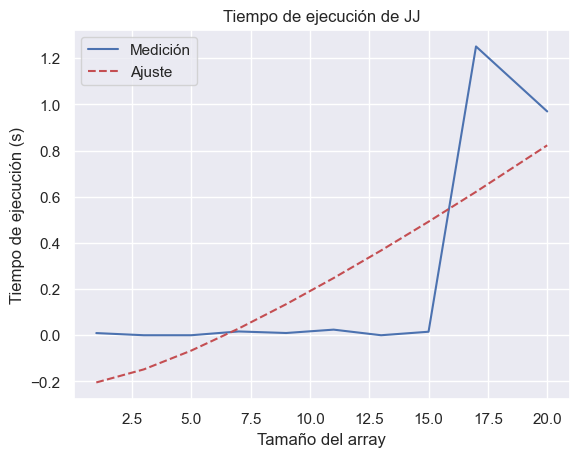

In [ ]:
ax.plot(x, [c[0] * n * np.log(n) + c[1] for n in x], 'r--', label="Ajuste")
ax.legend()
fig

Text(0, 0.5, 'Error absoluto (s)')

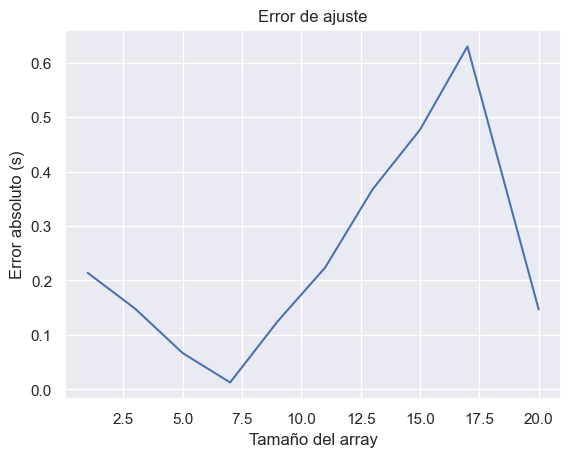

In [ ]:
ax: plt.Axes
fig, ax = plt.subplots()
errors = [np.abs(c[0] * n * np.log(n) + c[1] - results[n]) for n in x]
ax.plot(x, errors)
ax.set_title('Error de ajuste')
ax.set_xlabel('Tamaño del array')
ax.set_ylabel('Error absoluto (s)')